# Baseline CNN

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

### 1. Import libraries

In [ ]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

### 2. Use MPS

In [12]:
use_mps = True
print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")

MPS available: True
Using device: mps


### 3. Split Dataset 
- Use simpleCNN model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)


model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### 4. Train Model

In [14]:
best_val_loss = float("inf")

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

    # Save best model
    # if val_metrics["loss"] < best_val_loss:
    #     best_val_loss = val_metrics["loss"]
    #     torch.save(model.state_dict(), "../models/cnn_baseline.pth")
    #     print("Saved best model at epoch", epoch+1)

Epoch [1/20] | Train Loss: 0.3800, Train Acc: 0.8576 | Val Loss: 0.3361, Val Acc: 0.8576
Epoch [2/20] | Train Loss: 0.3271, Train Acc: 0.8576 | Val Loss: 0.3359, Val Acc: 0.8576
Epoch [3/20] | Train Loss: 0.3194, Train Acc: 0.8578 | Val Loss: 0.3260, Val Acc: 0.8576
Epoch [4/20] | Train Loss: 0.3208, Train Acc: 0.8584 | Val Loss: 0.3019, Val Acc: 0.8576
Epoch [5/20] | Train Loss: 0.3057, Train Acc: 0.8611 | Val Loss: 0.2934, Val Acc: 0.8653
Epoch [6/20] | Train Loss: 0.2964, Train Acc: 0.8633 | Val Loss: 0.3302, Val Acc: 0.8576
Epoch [7/20] | Train Loss: 0.2916, Train Acc: 0.8671 | Val Loss: 0.2878, Val Acc: 0.8713
Epoch [8/20] | Train Loss: 0.2811, Train Acc: 0.8721 | Val Loss: 0.3197, Val Acc: 0.8721
Epoch [9/20] | Train Loss: 0.2760, Train Acc: 0.8745 | Val Loss: 0.2765, Val Acc: 0.8832
Epoch [10/20] | Train Loss: 0.2765, Train Acc: 0.8770 | Val Loss: 0.2733, Val Acc: 0.8755
Epoch [11/20] | Train Loss: 0.2725, Train Acc: 0.8814 | Val Loss: 0.2886, Val Acc: 0.8696
Epoch [12/20] | Tra

### 5. Plot Loss and Accuracy Curves

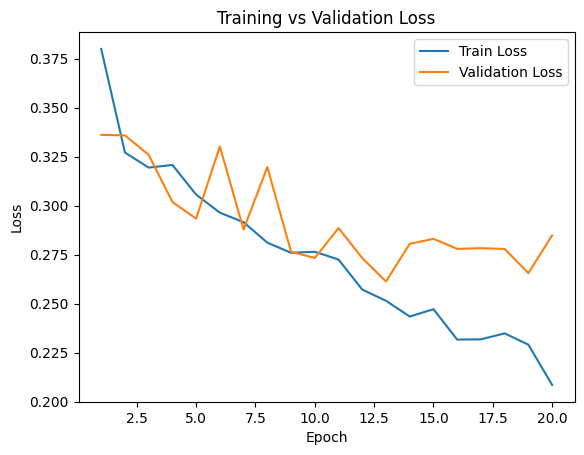

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

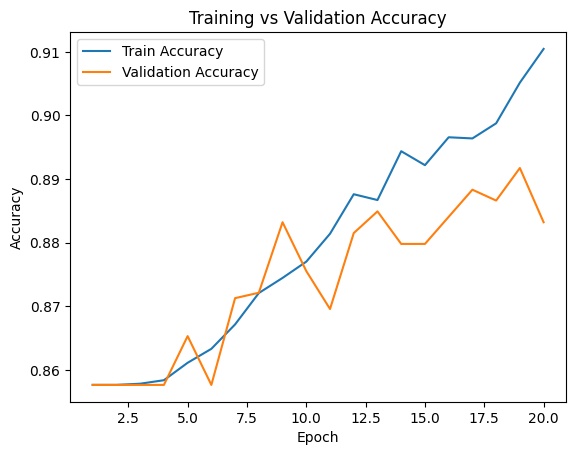

In [16]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [23]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= 0.5)            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [24]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[981  25]
 [ 97  70]]


In [25]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9100    0.9751    0.9415      1006
           1     0.7368    0.4192    0.5344       167

    accuracy                         0.8960      1173
   macro avg     0.8234    0.6972    0.7379      1173
weighted avg     0.8854    0.8960    0.8835      1173



- Class 0 (majority class)
    - Precision: 0.91
    - Recall: 0.975
    - F1: 0.94
Note: Good, model handles class 0 very well

- Class 1 (minority class)
    - Precision: 0.7368
    - Recall: 0.4192
    - F1: 0.5344
Note: The model is missing more than half of class 1 samples. **BAD**

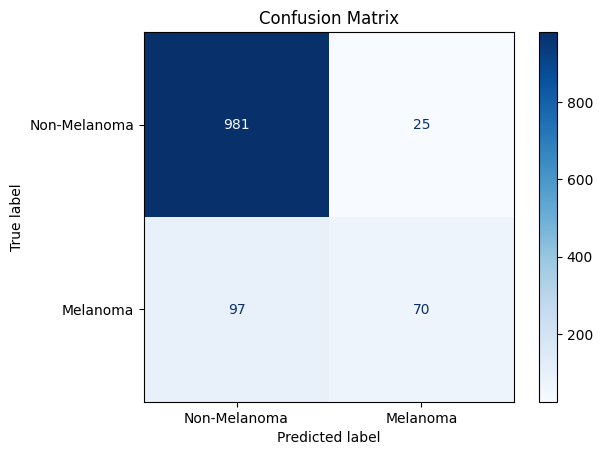

In [26]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()